<a href="https://colab.research.google.com/github/Bryan-Kweku-Wilson/Machine-Learning-Projects/blob/main/EcoCell_RL_04_Traffic_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
traffic_df = pd.read_csv(
    "ecocell_energy_qos.csv"
)

traffic_df.head()

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate,latency_ms,...,baseline_power_w,active_power_w,light_sleep_power_w,deep_sleep_power_w,bs_active_energy_kwh,light_sleep_energy_kwh,deep_sleep_energy_kwh,light_sleep_savings_kwh,deep_sleep_savings_kwh,network_active_energy_kwh
0,2026-01-01 00:00:00,BS00,urban,34.394687,17,984.792314,0.034926,34.394687,0.003310,18.827108,...,1435.786120,881.530079,574.314448,143.578612,0.881530,0.574314,0.143579,0.307216,0.737951,0.881530
1,2026-01-01 00:00:00,BS01,rural,29.212211,15,887.566412,0.032913,29.212211,0.009014,20.964499,...,967.693323,593.355756,387.077329,96.769332,0.593356,0.387077,0.096769,0.206278,0.496586,0.593356
2,2026-01-01 00:00:00,BS02,suburban,38.916347,19,969.749471,0.040130,38.916347,0.002017,18.629819,...,901.426410,555.325655,360.570564,90.142641,0.555326,0.360571,0.090143,0.194755,0.465183,0.555326
3,2026-01-01 00:00:00,BS03,suburban,33.128630,17,947.413675,0.034967,33.128630,0.001163,23.756477,...,1142.616932,701.551914,457.046773,114.261693,0.701552,0.457047,0.114262,0.244505,0.587290,0.701552
4,2026-01-01 00:00:00,BS04,urban,18.615690,9,798.949989,0.023300,18.615690,0.002295,21.127977,...,1489.955318,907.859690,595.982127,148.995532,0.907860,0.595982,0.148996,0.311878,0.758864,0.907860


In [ ]:
traffic_df["timestamp"] = pd.to_datetime(
    traffic_df["timestamp"], errors='coerce'
)

# Drop rows where timestamp became NaT
traffic_df = traffic_df.dropna(subset=["timestamp"]).reset_index(drop=True)

traffic_df = traffic_df.sort_values(
    ["bs_id", "timestamp"]
).reset_index(drop=True)

print("Rows after dropping invalid timestamps:", len(traffic_df))
traffic_df.head()

Rows after dropping invalid timestamps: 36000


,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate,latency_ms,...,baseline_power_w,active_power_w,light_sleep_power_w,deep_sleep_power_w,bs_active_energy_kwh,light_sleep_energy_kwh,deep_sleep_energy_kwh,light_sleep_savings_kwh,deep_sleep_savings_kwh,network_active_energy_kwh
0,2026-01-01 00:00:00,BS00,urban,34.394687,17,984.792314,0.034926,34.394687,0.003310,18.827108,...,1435.78612,881.530079,574.314448,143.578612,0.881530,0.574314,0.143579,0.307216,0.737951,0.881530
1,2026-01-01 01:00:00,BS00,urban,27.819057,14,984.792314,0.028249,27.819057,0.002137,19.935767,...,1435.78612,877.695282,574.314448,143.578612,0.877695,0.574314,0.143579,0.303381,0.734117,0.877695
2,2026-01-01 02:00:00,BS00,urban,24.800285,12,984.792314,0.025183,24.800285,0.005976,18.807378,...,1435.78612,875.934785,574.314448,143.578612,0.875935,0.574314,0.143579,0.301620,0.732356,0.875935
3,2026-01-01 03:00:00,BS00,urban,21.921201,11,984.792314,0.022260,21.921201,0.007164,21.420333,...,1435.78612,874.255751,574.314448,143.578612,0.874256,0.574314,0.143579,0.299941,0.730677,0.874256
4,2026-01-01 04:00:00,BS00,urban,21.291934,11,984.792314,0.021621,21.291934,0.002840,20.216609,...,1435.78612,873.888773,574.314448,143.578612,0.873889,0.574314,0.143579,0.299574,0.730310,0.873889


In [ ]:
traffic_df["traffic_lag_1"] = (
    traffic_df
    .groupby("bs_id")["traffic_mbps"]
    .shift(1)
)

traffic_df["traffic_lag_2"] = (
    traffic_df
    .groupby("bs_id")["traffic_mbps"]
    .shift(2)
)

traffic_df["traffic_lag_3"] = (
    traffic_df
    .groupby("bs_id")["traffic_mbps"]
    .shift(3)
)

traffic_df["traffic_lag_24"] = (
    traffic_df
    .groupby("bs_id")["traffic_mbps"]
    .shift(24)
)

traffic_df["traffic_lag_168"] = (
    traffic_df
    .groupby("bs_id")["traffic_mbps"]
    .shift(168)
)

In [ ]:
traffic_df["hour"] = (
    traffic_df["timestamp"].dt.hour
)

traffic_df["day_of_week"] = (
    traffic_df["timestamp"].dt.dayofweek
)

traffic_df["is_weekend"] = (
    traffic_df["day_of_week"] >= 5
).astype(int)

In [ ]:
traffic_df["target_traffic"] = (
    traffic_df
    .groupby("bs_id")["traffic_mbps"]
    .shift(-1)
)

In [ ]:
forecast_df = traffic_df.dropna(
    subset=[
        "traffic_lag_1",
        "traffic_lag_2",
        "traffic_lag_3",
        "traffic_lag_24",
        "target_traffic"
    ]
).copy()

print("Original rows:", len(traffic_df))
print("Forecasting rows:", len(forecast_df))

Original rows: 36000
Forecasting rows: 34750


In [ ]:
forecast_df[
    [
        "timestamp",
        "bs_id",
        "traffic_lag_1",
        "traffic_lag_2",
        "traffic_lag_3",
        "traffic_lag_24",
        "traffic_lag_168",
        "target_traffic"
    ]
].head(10)

,timestamp,bs_id,traffic_lag_1,traffic_lag_2,traffic_lag_3,traffic_lag_24,traffic_lag_168,target_traffic
24,2026-01-02 00:00:00,BS00,57.312257,87.183223,129.160240,34.394687,NaN,28.462800
25,2026-01-02 01:00:00,BS00,31.491079,57.312257,87.183223,27.819057,NaN,24.669954
26,2026-01-02 02:00:00,BS00,28.462800,31.491079,57.312257,24.800285,NaN,23.569794
27,2026-01-02 03:00:00,BS00,24.669954,28.462800,31.491079,21.921201,NaN,23.938817
28,2026-01-02 04:00:00,BS00,23.569794,24.669954,28.462800,21.291934,NaN,24.833849
29,2026-01-02 05:00:00,BS00,23.938817,23.569794,24.669954,25.548293,NaN,40.505750
30,2026-01-02 06:00:00,BS00,24.833849,23.938817,23.569794,37.924858,NaN,59.381152
31,2026-01-02 07:00:00,BS00,40.505750,24.833849,23.938817,60.283854,NaN,97.617031
32,2026-01-02 08:00:00,BS00,59.381152,40.505750,24.833849,100.421765,NaN,119.001287
33,2026-01-02 09:00:00,BS00,97.617031,59.381152,40.505750,113.593804,NaN,115.936985


In [ ]:
# Ensure forecast_df timestamp column is clean before calculating split_time
forecast_df_clean = forecast_df.dropna(subset=["timestamp"])

split_time = (
    forecast_df_clean["timestamp"].quantile(0.80)
)

print("Training ends before:", split_time)
print("Testing starts at:", split_time)

Training ends before: 2026-01-25 03:12:00
Testing starts at: 2026-01-25 03:12:00


In [ ]:
train_df = forecast_df_clean[
    forecast_df_clean["timestamp"] < split_time
].copy()

test_df = forecast_df_clean[
    forecast_df_clean["timestamp"] >= split_time
].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 27800
Testing rows: 6950


In [ ]:
test_df["naive_prediction"] = (
    test_df["traffic_lag_1"]
)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    test_df["target_traffic"].dropna(), # Explicitly drop NaNs
    test_df["naive_prediction"].dropna() # Explicitly drop NaNs
)

rmse = np.sqrt(
    mean_squared_error(
        test_df["target_traffic"].dropna(), # Explicitly drop NaNs
        test_df["naive_prediction"].dropna() # Explicitly drop NaNs
    )
)

print("Naive Baseline")
print("----------------")
print("MAE:", mae)
print("RMSE:", rmse)

Naive Baseline
----------------
MAE: 23.899173462930538
RMSE: 35.50210936940021


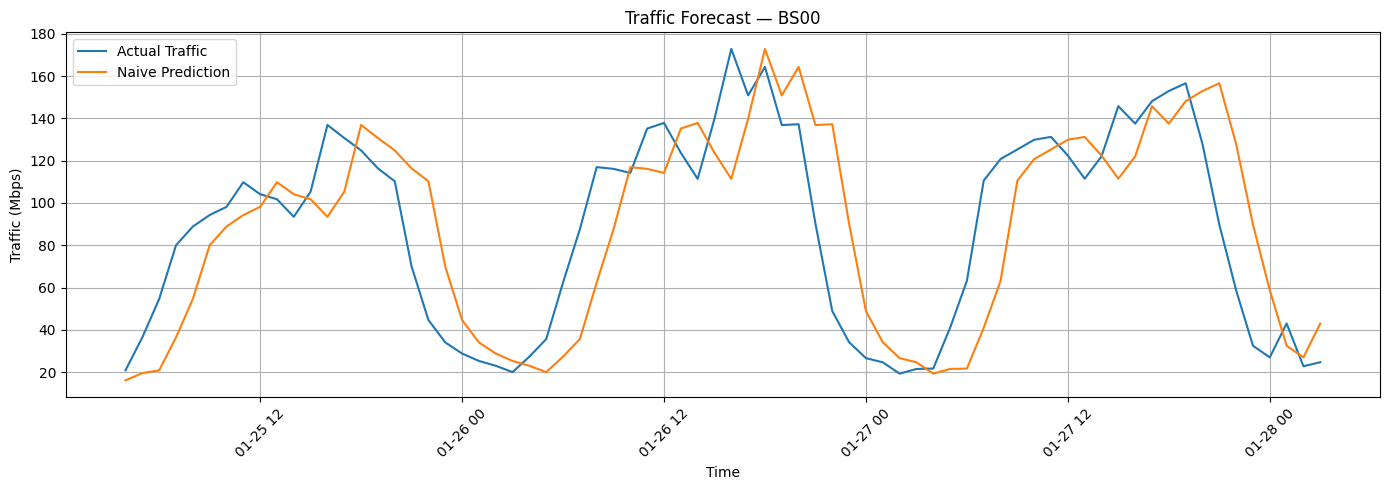

In [ ]:
sample_bs = "BS00"

sample_test = test_df[
    test_df["bs_id"] == sample_bs
].iloc[:72]

plt.figure(figsize=(14, 5))

plt.plot(
    sample_test["timestamp"],
    sample_test["target_traffic"],
    label="Actual Traffic"
)

plt.plot(
    sample_test["timestamp"],
    sample_test["naive_prediction"],
    label="Naive Prediction"
)

plt.title(
    f"Traffic Forecast — {sample_bs}"
)

plt.xlabel("Time")
plt.ylabel("Traffic (Mbps)")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
features = [
    "traffic_lag_1",
    "traffic_lag_2",
    "traffic_lag_3",
    "traffic_lag_24",
    "traffic_lag_168",
    "hour",
    "day_of_week",
    "is_weekend"
]

target = "target_traffic"

In [ ]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (27800, 8)
y_train: (27800,)
X_test: (6950, 8)
y_test: (6950,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
rf_predictions = rf_model.predict(
    X_test
)

test_df["rf_prediction"] = rf_predictions

In [ ]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

print("Random Forest")
print("----------------")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest
----------------
MAE: 8.233463885777164
RMSE: 16.68163737916503


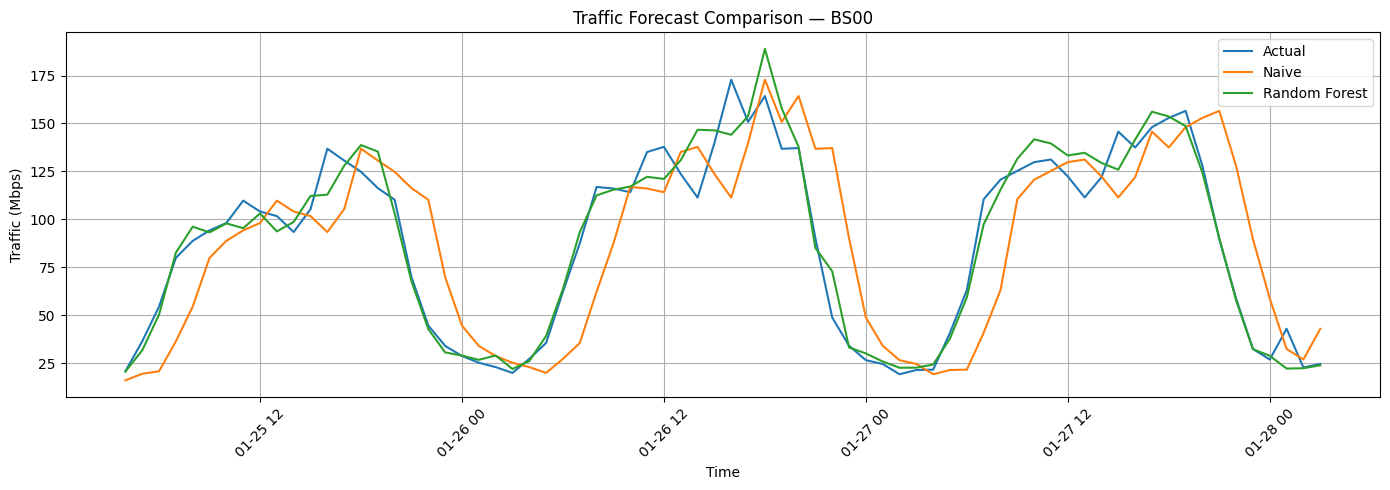

In [ ]:
sample_test = test_df[
    test_df["bs_id"] == sample_bs
].iloc[:72]

plt.figure(figsize=(14, 5))

plt.plot(
    sample_test["timestamp"],
    sample_test["target_traffic"],
    label="Actual"
)

plt.plot(
    sample_test["timestamp"],
    sample_test["naive_prediction"],
    label="Naive"
)

plt.plot(
    sample_test["timestamp"],
    sample_test["rf_prediction"],
    label="Random Forest"
)

plt.title(
    f"Traffic Forecast Comparison — {sample_bs}"
)

plt.xlabel("Time")
plt.ylabel("Traffic (Mbps)")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
test_df["rf_error"] = (
    test_df["target_traffic"]
    - test_df["rf_prediction"]
)

test_df["rf_absolute_error"] = (
    test_df["rf_error"].abs()
)

In [ ]:
worst_predictions = (
    test_df
    .sort_values(
        "rf_absolute_error",
        ascending=False
    )
    [[
        "timestamp",
        "bs_id",
        "target_traffic",
        "rf_prediction",
        "rf_absolute_error"
    ]]
    .head(10)
)

worst_predictions

,timestamp,bs_id,target_traffic,rf_prediction,rf_absolute_error
33081,2026-01-29 09:00:00,BS45,355.747162,138.642266,217.104896
7146,2026-01-28 18:00:00,BS09,401.758815,193.284601,208.474214
20050,2026-01-26 10:00:00,BS27,331.305901,125.415562,205.890339
33061,2026-01-28 13:00:00,BS45,333.864132,128.987830,204.876301
17948,2026-01-28 20:00:00,BS24,360.252132,160.411375,199.840758
33112,2026-01-30 16:00:00,BS45,354.638204,159.759715,194.878489
1385,2026-01-28 17:00:00,BS01,348.602425,158.170193,190.432232
34502,2026-01-28 14:00:00,BS47,303.253374,118.188232,185.065142
20033,2026-01-25 17:00:00,BS27,294.939250,115.526185,179.413065
14289,2026-01-26 09:00:00,BS19,279.203593,101.246414,177.957179


In [ ]:
print("traffic_spike" in test_df.columns)

True


In [ ]:
test_df.groupby("traffic_spike")[
    "rf_absolute_error"
].mean()

,rf_absolute_error
traffic_spike,
False,8.236126
True,8.100084


In [ ]:
print("traffic_spike" in test_df.columns)

True


In [ ]:
test_df.groupby("traffic_spike")["rf_absolute_error"].mean()

,rf_absolute_error
traffic_spike,
False,8.236126
True,8.100084


In [ ]:
test_df.groupby("traffic_spike")["rf_absolute_error"].mean()

,rf_absolute_error
traffic_spike,
False,8.236126
True,8.100084


In [ ]:
print("Overall MAE:", test_df["rf_absolute_error"].mean())

Overall MAE: 8.233463885777164


In [ ]:
print(test_df.shape)
print(test_df["traffic_spike"].value_counts())

(6950, 35)
traffic_spike
False    6814
True      136
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rf_mae = test_df["rf_absolute_error"].mean()

rf_rmse = np.sqrt(
    mean_squared_error(
        test_df["target_traffic"],
        test_df["rf_prediction"]
    )
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 8.233463885777164
Random Forest RMSE: 16.68163737916503


In [ ]:
naive_mae = mean_absolute_error(
    test_df["target_traffic"],
    test_df["naive_prediction"]
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test_df["target_traffic"],
        test_df["naive_prediction"]
    )
)

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)

Naive MAE: 23.899173462930538
Naive RMSE: 35.50210936940021


In [ ]:
mae_improvement = (
    (naive_mae - rf_mae) / naive_mae
) * 100

rmse_improvement = (
    (naive_rmse - rf_rmse) / naive_rmse
) * 100

print("MAE improvement:", mae_improvement, "%")
print("RMSE improvement:", rmse_improvement, "%")

MAE improvement: 65.54916889260667 %
RMSE improvement: 53.01226412889377 %


In [ ]:
# ============================================
# GRU TRAFFIC FORECASTING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

traffic_df = pd.read_csv("ecocell_energy_qos.csv")

traffic_df["timestamp"] = pd.to_datetime(
    traffic_df["timestamp"]
)

traffic_df = traffic_df.sort_values(
    ["bs_id", "timestamp"]
).reset_index(drop=True)

print(traffic_df.head())
print(traffic_df.shape)

            timestamp bs_id cell_type  traffic_mbps  active_users  \
0 2026-01-01 00:00:00  BS00     urban     34.394687            17   
1 2026-01-01 01:00:00  BS00     urban     27.819057            14   
2 2026-01-01 02:00:00  BS00     urban     24.800285            12   
3 2026-01-01 03:00:00  BS00     urban     21.921201            11   
4 2026-01-01 04:00:00  BS00     urban     21.291934            11   

   capacity_mbps  utilization  throughput_mbps  packet_loss_rate  latency_ms  \
0     984.792314     0.034926        34.394687          0.003310   18.827108   
1     984.792314     0.028249        27.819057          0.002137   19.935767   
2     984.792314     0.025183        24.800285          0.005976   18.807378   
3     984.792314     0.022260        21.921201          0.007164   21.420333   
4     984.792314     0.021621        21.291934          0.002840   20.216609   

   ...  baseline_power_w  active_power_w  light_sleep_power_w  \
0  ...        1435.78612      881.53007

In [ ]:
bs_id = "BS00"

bs_df = traffic_df[
    traffic_df["bs_id"] == bs_id
].copy()

bs_df = bs_df.sort_values("timestamp")

print(bs_df[[
    "timestamp",
    "traffic_mbps"
]].head(10))

            timestamp  traffic_mbps
0 2026-01-01 00:00:00     34.394687
1 2026-01-01 01:00:00     27.819057
2 2026-01-01 02:00:00     24.800285
3 2026-01-01 03:00:00     21.921201
4 2026-01-01 04:00:00     21.291934
5 2026-01-01 05:00:00     25.548293
6 2026-01-01 06:00:00     37.924858
7 2026-01-01 07:00:00     60.283854
8 2026-01-01 08:00:00    100.421765
9 2026-01-01 09:00:00    113.593804


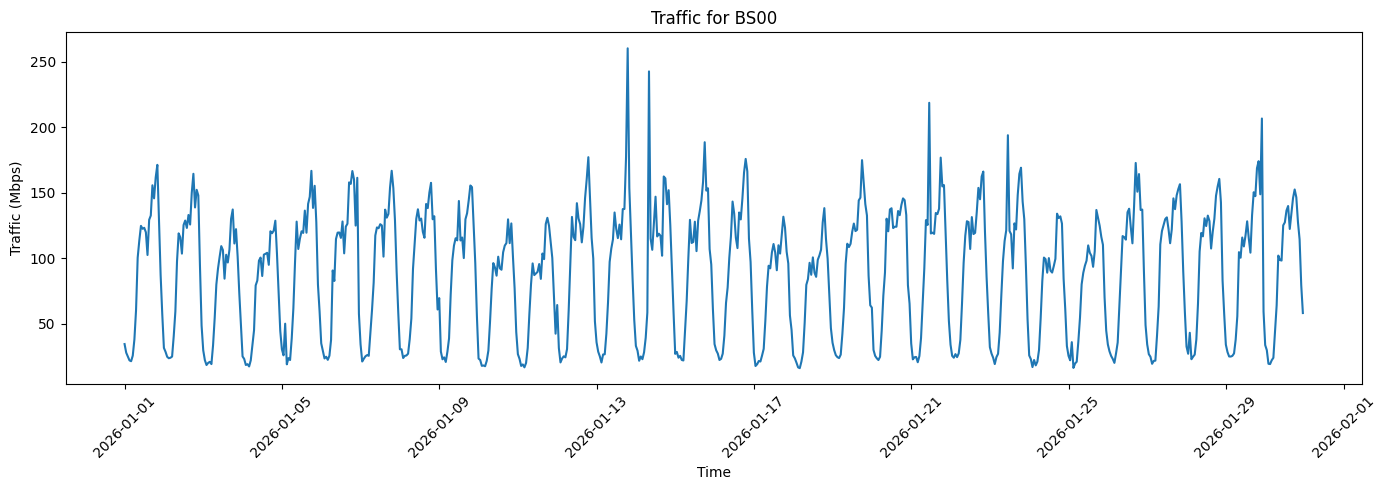

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    bs_df["timestamp"],
    bs_df["traffic_mbps"]
)

plt.xlabel("Time")
plt.ylabel("Traffic (Mbps)")
plt.title(f"Traffic for {bs_id}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

bs_df["traffic_scaled"] = scaler.fit_transform(
    bs_df[["traffic_mbps"]]
)

print(
    bs_df[
        ["traffic_mbps", "traffic_scaled"]
    ].head(10)
)

   traffic_mbps  traffic_scaled
0     34.394687        0.075375
1     27.819057        0.048474
2     24.800285        0.036125
3     21.921201        0.024346
4     21.291934        0.021772
5     25.548293        0.039185
6     37.924858        0.089817
7     60.283854        0.181288
8    100.421765        0.345493
9    113.593804        0.399380


In [ ]:
SEQUENCE_LENGTH = 24

traffic_values = bs_df["traffic_scaled"].values

X = []
y = []

for i in range(SEQUENCE_LENGTH, len(traffic_values)):
    X.append(
        traffic_values[i-SEQUENCE_LENGTH:i]
    )

    y.append(
        traffic_values[i]
    )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (696, 24)
y shape: (696,)


In [ ]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (696, 24, 1)
y shape: (696,)


In [ ]:
train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (556, 24, 1)
X_test shape: (140, 24, 1)
y_train shape: (556,)
y_test shape: (140,)


In [ ]:
traffic_values = bs_df["traffic_mbps"].values

print("Number of observations:", len(traffic_values))

Number of observations: 720


In [ ]:
split_point = int(len(traffic_values) * 0.80)

train_values = traffic_values[:split_point]
test_values = traffic_values[split_point:]

print("Training observations:", len(train_values))
print("Testing observations:", len(test_values))

Training observations: 576
Testing observations: 144


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_values.reshape(-1, 1)
)

test_scaled = scaler.transform(
    test_values.reshape(-1, 1)
)

print("Training scaled shape:", train_scaled.shape)
print("Testing scaled shape:", test_scaled.shape)

Training scaled shape: (576, 1)
Testing scaled shape: (144, 1)


In [ ]:
SEQUENCE_LENGTH = 24

X_train = []
y_train = []

for i in range(SEQUENCE_LENGTH, len(train_scaled)):
    X_train.append(
        train_scaled[i-SEQUENCE_LENGTH:i]
    )

    y_train.append(
        train_scaled[i]
    )

X_train = np.array(X_train)
y_train = np.array(y_train)

In [ ]:
test_input = np.concatenate([
    train_scaled[-SEQUENCE_LENGTH:],
    test_scaled
])

In [ ]:
X_test = []
y_test = []

for i in range(SEQUENCE_LENGTH, len(test_input)):
    X_test.append(
        test_input[i-SEQUENCE_LENGTH:i]
    )

    y_test.append(
        test_input[i]
    )

X_test = np.array(X_test)
y_test = np.array(y_test)

In [ ]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (552, 24, 1)
y_train shape: (552, 1)
X_test shape: (144, 24, 1)
y_test shape: (144, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [ ]:
gru_model = Sequential([
    GRU(
        64,
        input_shape=(24, 1)
    ),

    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = gru_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0406 - mae: 0.1638 - val_loss: 0.0292 - val_mae: 0.1358
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0220 - mae: 0.1224 - val_loss: 0.0219 - val_mae: 0.1275
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0181 - mae: 0.1129 - val_loss: 0.0186 - val_mae: 0.1145
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0154 - mae: 0.1007 - val_loss: 0.0157 - val_mae: 0.1058
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0127 - mae: 0.0910 - val_loss: 0.0133 - val_mae: 0.0976
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0104 - mae: 0.0781 - val_loss: 0.0108 - val_mae: 0.0859
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0087 - mae: 0.0685 - val_loss: 0.0099 - val_mae: 0.0804
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0080 - mae: 0.0655 - val_loss: 0.0094 - val_mae: 0.0766
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.007

In [ ]:
pred_scaled = gru_model.predict(X_test)

print("Prediction shape:", pred_scaled.shape)
print("Actual shape:", y_test.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction shape: (144, 1)
Actual shape: (144, 1)


In [ ]:
pred_mbps = scaler.inverse_transform(pred_scaled)
y_test_mbps = scaler.inverse_transform(y_test)

print("First 10 predictions:")
print(pred_mbps[:10].flatten())

print("\nFirst 10 actual values:")
print(y_test_mbps[:10].flatten())

First 10 predictions:
[32.662025 26.705969 28.672941 42.636097 37.320335 37.50882  40.712955
 53.44539  71.10322  93.779526]

First 10 actual values:
[25.35683079 21.9923062  35.84999202 16.15393801 19.56406261 20.89261846
 36.46114905 54.60236283 79.97958073 88.83541778]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    y_test_mbps,
    pred_mbps
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_mbps,
        pred_mbps
    )
)

print("GRU MAE:", mae)
print("GRU RMSE:", rmse)

GRU MAE: 13.573175435401067
GRU RMSE: 19.147945272281312


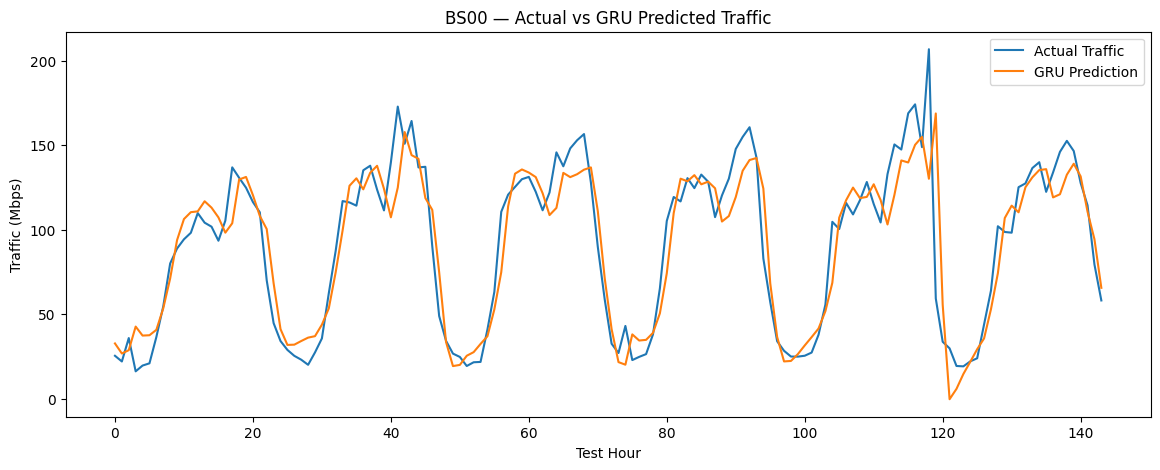

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    y_test_mbps.flatten(),
    label="Actual Traffic"
)

plt.plot(
    pred_mbps.flatten(),
    label="GRU Prediction"
)

plt.title("BS00 — Actual vs GRU Predicted Traffic")
plt.xlabel("Test Hour")
plt.ylabel("Traffic (Mbps)")
plt.legend()
plt.show()

In [ ]:
# Create a results dataframe
results_df = pd.DataFrame({
    "actual": y_test_mbps.flatten(),
    "prediction": pred_mbps.flatten()
})

# Calculate absolute error
results_df["absolute_error"] = (
    results_df["actual"] - results_df["prediction"]
).abs()

# Define traffic levels
results_df["traffic_level"] = pd.cut(
    results_df["actual"],
    bins=[-np.inf, 50, 100, 150, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

# Calculate MAE for each traffic level
error_by_level = results_df.groupby(
    "traffic_level",
    observed=True
)["absolute_error"].mean()

print(error_by_level)

traffic_level
Low           9.587411
Medium       17.776436
High         12.130617
Very High    27.945251
Name: absolute_error, dtype: float64


In [ ]:
# Check whether the test period contains traffic spikes
spike_mask = bs_df["traffic_spike"].iloc[-144:].values

results_df["traffic_spike"] = spike_mask

spike_error = results_df.groupby(
    "traffic_spike"
)["absolute_error"].mean()

print(spike_error)

traffic_spike
False    13.104690
True     35.592006
Name: absolute_error, dtype: float64


In [ ]:
traffic_df

,timestamp,bs_id,cell_type,traffic_mbps,active_users,capacity_mbps,utilization,throughput_mbps,packet_loss_rate,latency_ms,...,baseline_power_w,active_power_w,light_sleep_power_w,deep_sleep_power_w,bs_active_energy_kwh,light_sleep_energy_kwh,deep_sleep_energy_kwh,light_sleep_savings_kwh,deep_sleep_savings_kwh,network_active_energy_kwh
0,2026-01-01 00:00:00,BS00,urban,34.394687,17,984.792314,0.034926,34.394687,0.003310,18.827108,...,1435.786120,881.530079,574.314448,143.578612,0.881530,0.574314,0.143579,0.307216,0.737951,0.881530
1,2026-01-01 01:00:00,BS00,urban,27.819057,14,984.792314,0.028249,27.819057,0.002137,19.935767,...,1435.786120,877.695282,574.314448,143.578612,0.877695,0.574314,0.143579,0.303381,0.734117,0.877695
2,2026-01-01 02:00:00,BS00,urban,24.800285,12,984.792314,0.025183,24.800285,0.005976,18.807378,...,1435.786120,875.934785,574.314448,143.578612,0.875935,0.574314,0.143579,0.301620,0.732356,0.875935
3,2026-01-01 03:00:00,BS00,urban,21.921201,11,984.792314,0.022260,21.921201,0.007164,21.420333,...,1435.786120,874.255751,574.314448,143.578612,0.874256,0.574314,0.143579,0.299941,0.730677,0.874256
4,2026-01-01 04:00:00,BS00,urban,21.291934,11,984.792314,0.021621,21.291934,0.002840,20.216609,...,1435.786120,873.888773,574.314448,143.578612,0.873889,0.574314,0.143579,0.299574,0.730310,0.873889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,2026-01-30 19:00:00,BS49,urban,113.145190,57,553.945713,0.204253,113.145190,0.009416,20.951100,...,1345.912882,917.510540,538.365153,134.591288,0.917511,0.538365,0.134591,0.379145,0.782919,0.917511
35996,2026-01-30 20:00:00,BS49,urban,106.185648,53,553.945713,0.191690,106.185648,0.004360,20.058273,...,1345.912882,910.746745,538.365153,134.591288,0.910747,0.538365,0.134591,0.372382,0.776155,0.910747
35997,2026-01-30 21:00:00,BS49,urban,80.478548,40,553.945713,0.145282,80.478548,0.003442,14.784481,...,1345.912882,885.762697,538.365153,134.591288,0.885763,0.538365,0.134591,0.347398,0.751171,0.885763
35998,2026-01-30 22:00:00,BS49,urban,57.749624,29,553.945713,0.104251,57.749624,0.002695,17.980538,...,1345.912882,863.673058,538.365153,134.591288,0.863673,0.538365,0.134591,0.325308,0.729082,0.863673


In [ ]:
bs_id
bs_df["timestamp"]

,timestamp
0,2026-01-01 00:00:00
1,2026-01-01 01:00:00
2,2026-01-01 02:00:00
3,2026-01-01 03:00:00
4,2026-01-01 04:00:00
...,...
715,2026-01-30 19:00:00
716,2026-01-30 20:00:00
717,2026-01-30 21:00:00
718,2026-01-30 22:00:00


In [ ]:
# Create train/test traffic data for all base stations

train_parts = []
test_parts = []

for bs_id, group in traffic_df.groupby("bs_id"):

    # Sort chronologically
    group = group.sort_values("timestamp").copy()

    # 80% training split
    split_point = int(len(group) * 0.80)

    train_group = group.iloc[:split_point].copy()
    test_group = group.iloc[split_point:].copy()

    train_parts.append(train_group)
    test_parts.append(test_group)

# Combine all base stations
train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (28800, 22)
Testing shape: (7200, 22)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scalers = {}

train_scaled_parts = []
test_scaled_parts = []

for bs_id in train_df["bs_id"].unique():

    # Get this base station's training and testing data
    train_group = train_df[train_df["bs_id"] == bs_id].copy()
    test_group = test_df[test_df["bs_id"] == bs_id].copy()

    # Create a scaler specifically for this base station
    scaler = MinMaxScaler()

    # Fit ONLY on training traffic
    train_group["traffic_scaled"] = scaler.fit_transform(
        train_group[["traffic_mbps"]]
    )

    # Use the same scaler to transform test traffic
    test_group["traffic_scaled"] = scaler.transform(
        test_group[["traffic_mbps"]]
    )

    # Store the scaler so we can later convert predictions
    # back into Mbps
    scalers[bs_id] = scaler

    train_scaled_parts.append(train_group)
    test_scaled_parts.append(test_group)

# Combine everything back together
train_scaled_df = pd.concat(
    train_scaled_parts,
    ignore_index=True
)

test_scaled_df = pd.concat(
    test_scaled_parts,
    ignore_index=True
)

print("Scaled training shape:", train_scaled_df.shape)
print("Scaled testing shape:", test_scaled_df.shape)

Scaled training shape: (28800, 23)
Scaled testing shape: (7200, 23)


In [ ]:
scaler.fit(train_values.reshape(-1, 1))

MinMaxScaler()

In [ ]:
SEQUENCE_LENGTH = 24

X_train = []
y_train = []

X_test = []
y_test = []

# Keep track of which base station each sequence belongs to
train_bs_ids = []
test_bs_ids = []

for bs_id in train_scaled_df["bs_id"].unique():

    # -------------------------
    # Get this BS's data
    # -------------------------
    train_group = train_scaled_df[
        train_scaled_df["bs_id"] == bs_id
    ].sort_values("timestamp")

    test_group = test_scaled_df[
        test_scaled_df["bs_id"] == bs_id
    ].sort_values("timestamp")

    train_values = train_group["traffic_scaled"].values
    test_values = test_group["traffic_scaled"].values

    # -------------------------
    # Create training sequences
    # -------------------------
    for i in range(SEQUENCE_LENGTH, len(train_values)):

        X_train.append(
            train_values[i-SEQUENCE_LENGTH:i]
        )

        y_train.append(
            train_values[i]
        )

        train_bs_ids.append(bs_id)

    # -------------------------
    # Create test sequences
    # -------------------------
    # Include the final 24 training observations
    # as context for the first test prediction
    test_input = np.concatenate([
        train_values[-SEQUENCE_LENGTH:],
        test_values
    ])

    for i in range(SEQUENCE_LENGTH, len(test_input)):

        X_test.append(
            test_input[i-SEQUENCE_LENGTH:i]
        )

        y_test.append(
            test_input[i]
        )

        test_bs_ids.append(bs_id)


# Convert lists to NumPy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

# Reshape X for the GRU:
# (samples, timesteps, features)
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Number of training sequences:", len(X_train))
print("Number of testing sequences:", len(X_test))

X_train shape: (27600, 24, 1)
y_train shape: (27600,)
X_test shape: (7200, 24, 1)
y_test shape: (7200,)
Number of training sequences: 27600
Number of testing sequences: 7200


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

gru_model_all = Sequential([
    GRU(
        64,
        input_shape=(SEQUENCE_LENGTH, 1)
    ),
    Dense(1)
])

gru_model_all.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model_all.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense

gru_model_all = Sequential([
    Input(shape=(SEQUENCE_LENGTH, 1)),
    GRU(64),
    Dense(1)
])

gru_model_all.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model_all.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_all = gru_model_all.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
777/777 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0083 - mae: 0.0608 - val_loss: 0.0071 - val_mae: 0.0555
Epoch 2/30
777/777 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 0.0048 - mae: 0.0431 - val_loss: 0.0047 - val_mae: 0.0429
Epoch 3/30
777/777 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0040 - mae: 0.0372 - val_loss: 0.0040 - val_mae: 0.0335
Epoch 4/30
777/777 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - loss: 0.0037 - mae: 0.0344 - val_loss: 0.0040 - val_mae: 0.0332
Epoch 5/30
777/777 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - loss: 0.0036 - mae: 0.0338 - val_loss: 0.0040 - val_mae: 0.0342
Epoch 6/30
777/777 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.0035 - mae: 0.0329 - val_loss: 0.0040 - val_mae: 0.0345
Epoch 7/30
777/777 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0035 - mae: 0.0324 - val_loss: 0.0038 - val_mae: 0.0314
Epoch 8/30
777/777 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0034 - mae: 0.0323 - val_loss: 0.0038 - val_mae: 0.0299
Epoch 9/30
777/777 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Generate predictions on the test set
pred_scaled = gru_model_all.predict(X_test)

print("Prediction shape:", pred_scaled.shape)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Prediction shape: (7200, 1)


In [ ]:
# Convert scaled predictions and actual values back to Mbps

pred_mbps = []
actual_mbps = []

for i, bs_id in enumerate(test_bs_ids):

    scaler = scalers[bs_id]

    prediction = scaler.inverse_transform(
        pred_scaled[i].reshape(-1, 1)
    )[0, 0]

    actual = scaler.inverse_transform(
        y_test[i].reshape(-1, 1)
    )[0, 0]

    pred_mbps.append(prediction)
    actual_mbps.append(actual)

pred_mbps = np.array(pred_mbps)
actual_mbps = np.array(actual_mbps)

print("Predictions shape:", pred_mbps.shape)
print("Actual values shape:", actual_mbps.shape)

Predictions shape: (7200,)
Actual values shape: (7200,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

gru_mae = mean_absolute_error(
    actual_mbps,
    pred_mbps
)

gru_rmse = np.sqrt(
    mean_squared_error(
        actual_mbps,
        pred_mbps
    )
)

print("GRU MAE:", gru_mae, "Mbps")
print("GRU RMSE:", gru_rmse, "Mbps")

GRU MAE: 7.9182926126243185 Mbps
GRU RMSE: 16.06281491216854 Mbps


In [ ]:
gru_results = pd.DataFrame({
    "bs_id": test_bs_ids,
    "actual_mbps": actual_mbps,
    "predicted_mbps": pred_mbps
})

gru_results["absolute_error"] = (
    np.abs(
        gru_results["actual_mbps"]
        - gru_results["predicted_mbps"]
    )
)

gru_results["squared_error"] = (
    gru_results["actual_mbps"]
    - gru_results["predicted_mbps"]
) ** 2

print(gru_results.head())
print("\nShape:", gru_results.shape)

  bs_id  actual_mbps  predicted_mbps  absolute_error  squared_error
0  BS00    25.356831       24.710905        0.645926       0.417220
1  BS00    21.992306       22.313150        0.320844       0.102941
2  BS00    35.849992       22.217714       13.632278     185.838996
3  BS00    16.153938       24.653896        8.499958      72.249291
4  BS00    19.564063       22.007811        2.443748       5.971904

Shape: (7200, 5)


In [ ]:
# Create traffic-level categories based on actual traffic

gru_results["traffic_level"] = pd.qcut(
    gru_results["actual_mbps"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

print(
    gru_results.groupby("traffic_level", observed=True)["absolute_error"]
    .mean()
)

traffic_level
Low           2.386834
Medium        5.821516
High          8.571741
Very High    14.893079
Name: absolute_error, dtype: float64


In [ ]:
test_spike_flags = []

# Re-create traffic_spike column for test_df if it doesn't exist.
# This is necessary because traffic_df was reloaded in the GRU section
# and previous feature engineering was lost.
if "traffic_spike" not in test_df.columns:
    # Define traffic spike as traffic_mbps exceeding the 95th percentile.
    # This definition can be adjusted based on the original intent.
    traffic_threshold = test_df["traffic_mbps"].quantile(0.95)
    test_df["traffic_spike"] = (
        test_df["traffic_mbps"] > traffic_threshold
    )

# Directly assign the traffic_spike column from test_df,
# as test_df is already aligned with gru_results in terms of order.
gru_results["traffic_spike"] = test_df["traffic_spike"].values

print(
    gru_results["traffic_spike"].value_counts()
)

traffic_spike
False    7057
True      143
Name: count, dtype: int64


In [ ]:
spike_mae = (
    gru_results
    .groupby("traffic_spike")["absolute_error"]
    .mean()
)

print(spike_mae)

traffic_spike
False     6.524399
True     76.706464
Name: absolute_error, dtype: float64


In [ ]:
spike_rmse = (
    gru_results
    .groupby("traffic_spike")["squared_error"]
    .mean()
    .apply(np.sqrt)
)

print("\nRMSE:")
print(spike_rmse)


RMSE:
traffic_spike
False     9.321428
True     93.289727
Name: squared_error, dtype: float64


In [ ]:
gru_results["signed_error"] = (
    gru_results["actual_mbps"]
    - gru_results["predicted_mbps"]
)

spike_signed_error = (
    gru_results[gru_results["traffic_spike"] == True]
    ["signed_error"]
)

print("Mean signed error during spikes:",
      spike_signed_error.mean())

print("Median signed error during spikes:",
      spike_signed_error.median())

print("Underpredictions:",
      (spike_signed_error > 0).sum())

print("Overpredictions:",
      (spike_signed_error < 0).sum())

Mean signed error during spikes: 76.70646379347056
Median signed error during spikes: 66.57203888255987
Underpredictions: 143
Overpredictions: 0
